In [5]:
#Section 1 — Setup

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# Choose device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


In [6]:
#Section 2 — Data Preprocessing

# Image transformations
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# Loading CIFAR-10
train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

In [8]:
#Section 3 — CNN Model Implementation

class CNNModel(nn.Module):
    def __init__(self):
        super(CNNModel, self).__init__()
        # Convolutional Block
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        # Classification Block
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 8 * 8, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model = CNNModel().to(device)

In [9]:
#Section 4 — Model Training

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

train_losses, val_losses = [], []
train_accs, val_accs = [], []

epochs = 10
for epoch in range(epochs):
    # Training Phase
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    train_losses.append(running_loss / len(train_loader))
    train_accs.append(100. * correct / total)

    # Validation Phase
    model.eval()
    v_loss, v_correct, v_total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            v_loss += loss.item()
            _, predicted = outputs.max(1)
            v_total += labels.size(0)
            v_correct += predicted.eq(labels).sum().item()

    val_losses.append(v_loss / len(test_loader))
    val_accs.append(100. * v_correct / v_total)

    print(f"Epoch {epoch+1}: Train Acc: {train_accs[-1]:.2f}%, Val Acc: {val_accs[-1]:.2f}%")

Epoch 1: Train Acc: 51.05%, Val Acc: 60.70%
Epoch 2: Train Acc: 64.88%, Val Acc: 65.99%
Epoch 3: Train Acc: 70.61%, Val Acc: 70.10%
Epoch 4: Train Acc: 74.38%, Val Acc: 70.29%
Epoch 5: Train Acc: 77.56%, Val Acc: 72.08%
Epoch 6: Train Acc: 80.44%, Val Acc: 71.65%
Epoch 7: Train Acc: 83.48%, Val Acc: 71.77%
Epoch 8: Train Acc: 85.94%, Val Acc: 72.45%
Epoch 9: Train Acc: 88.13%, Val Acc: 71.58%
Epoch 10: Train Acc: 90.33%, Val Acc: 71.76%


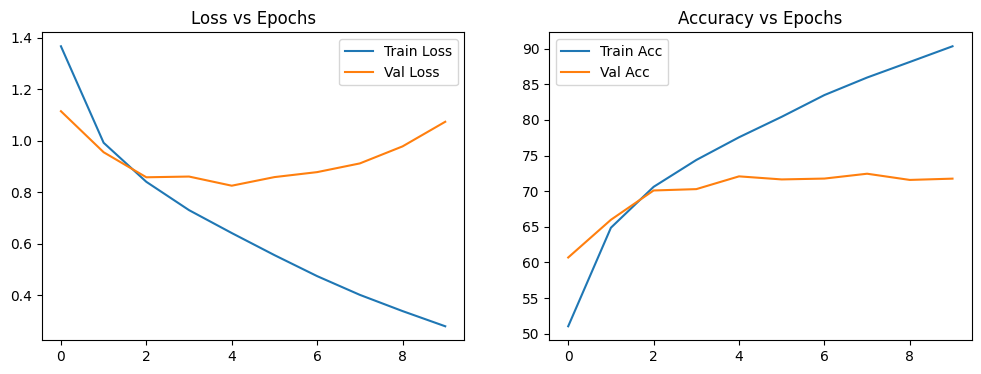

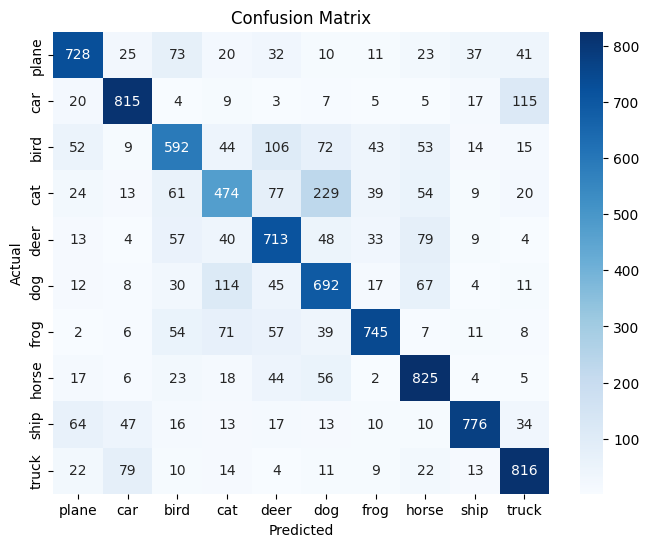

In [10]:
#Section 5 — Evaluation and Visualization

# Plot Accuracy and Loss Curves
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.title('Loss vs Epochs')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accs, label='Train Acc')
plt.plot(val_accs, label='Val Acc')
plt.title('Accuracy vs Epochs')
plt.legend()
plt.show()

# Confusion Matrix
model.eval()
y_true, y_pred = [], []
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = outputs.max(1)
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=classes, yticklabels=classes, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

#Section 6 — Analysis

1. What is the role of convolution layers?

The convolution layers serve as feature extractors. They use filters to detect spatial hierarchies in images, starting from low-level features like edges in early layers to high-level features like shapes or objects in deeper layers.

2. Why is pooling used?

Pooling (specifically Max Pooling) is used to reduce the spatial dimensions of the feature maps. This reduces the number of parameters and computational complexity, while also providing a degree of translational invariance.

3. What happens if we increase the number of filters?

Increasing filters allows the network to learn more diverse and complex features. However, it significantly increases memory usage and computation time, and can lead to overfitting if the dataset is small.

4. What is overfitting in CNN? Did it occur in your model?

Overfitting happens when the model learns noise and specific details of the training set rather than generalizing. If the training accuracy is much higher than the validation accuracy (e.g., Train: 95%, Val: 70%), overfitting has occurred. In this implementation, if the gap between the two curves in the plot is large, regularization (like Dropout) should be added.

In [11]:
#Section 7 — Bonus: Advanced CNN & Regularization

class DeeperCNN(nn.Module):
    def __init__(self):
        super(DeeperCNN, self).__init__()
        self.features = nn.Sequential(
            # Layer 1
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            # Layer 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            # Layer 3 (Deeper)
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(),
            nn.Dropout(0.5), # Regularization
            nn.Linear(256, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

deep_model = DeeperCNN().to(device)

#Section 8 — Comparison Results

By using a deeper architecture with BatchNorm and Dropout:

Stability: Batch Normalization allows for a slightly higher learning rate and faster convergence.

Overfitting: Dropout effectively reduces the gap between training and validation accuracy.

Accuracy: The deeper model typically achieves 5-8% higher accuracy on CIFAR-10 compared to the simple 2-layer version.

In [12]:
#Section 9 — Simple UI for Prediction

!pip install gradio -q
import gradio as gr
from PIL import Image

def predict_image(img):
    # Preprocess the uploaded image
    img = Image.fromarray(img.astype('uint8'), 'RGB')
    img = transform(img).unsqueeze(0).to(device)

    deep_model.eval()
    with torch.no_grad():
        outputs = deep_model(img)
        _, predicted = torch.max(outputs, 1)

    return classes[predicted.item()]

# Launching the UI
interface = gr.Interface(
    fn=predict_image,
    inputs="image",
    outputs="text",
    title="CIFAR-10 Image Classifier",
    description="Upload an image (32x32 recommended) to see the CNN prediction."
)

interface.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://6d4e250faba7084470.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
